# 04 — Redes Convolucionales 1D (Conv1D)
Input `(N, V_in, 23)`. Conv1D extrae patrones locales en la dimensión temporal.
Catálogo activo: **conv_s** (Conv1D + GlobalAvgPool). Descomentar `[EXTENDER]` para más variantes.

> Nota: Conv1D requiere V_in ≥ kernel_size (3). Para V_in=5 funciona correctamente.

https://github.com/Romequinco/TAREA_REDES_NEURONALES

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, yfinance as yf
import tensorflow as tf

warnings.simplefilter('ignore')

from keras import Sequential, Input
from keras.layers import Conv1D, GlobalAveragePooling1D, GlobalMaxPooling1D, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, GlobalAveragePooling1D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

from utils import (TICKERS, INPUT_WINDOWS, OUTPUT_WINDOWS,
                   create_time_series_data, make_splits, eval_mae,
                   get_callbacks, restore_best_weights, compile_model,
                   plot_mae_matrix, build_results_df, best_per_window)

In [4]:
# ── HIPERPARÁMETROS ───────────────────────────────────────────
EPOCHS     = 700
BATCH_SIZE = 64
QUICK_MODE = False
if QUICK_MODE: EPOCHS = 50

precios = yf.download(TICKERS, start='1960-01-01', auto_adjust=True, progress=False)['Close']
precios.dropna(axis=1, inplace=True)
returns = np.log(precios).diff().dropna()
print(f'Retornos: {returns.shape}  |  EPOCHS={EPOCHS}')

Retornos: (16200, 23)  |  EPOCHS=700


## Tamaños de Ventanas 

Existen **16 posibles combinaciones** de tamaños de ventanas de entrada-salida. Estas combinaciones se obtienen al cruzar las ventanas de entrada (`V_in`) con las ventanas de salida (`V_out`).

Las combinaciones consideradas son:

| Nº | `V_in` días | `V_out` días |
|---:|------------:|-------------:|
| 1  | 5  | 1  |
| 2  | 5  | 5  |
| 3  | 5  | 30 |
| 4  | 5  | 90 |
| 5  | 10 | 1  |
| 6  | 10 | 5  |
| 7  | 10 | 30 |
| 8  | 10 | 90 |
| 9  | 30 | 1  |
| 10 | 30 | 5  |
| 11 | 30 | 30 |
| 12 | 30 | 90 |
| 13 | 90 | 1  |
| 14 | 90 | 5  |
| 15 | 90 | 30 |
| 16 | 90 | 90 |

Se entrenará **un modelo para cada combinación de ventanas**, con el objetivo de comparar su rendimiento y determinar cuál de ellas ofrece la mejor opción.

In [ ]:
raise RuntimeError("Cortafuegos: no ejecutar las celdas siguientes con Run All")

# Implementación de los modelos básicos

## Arquitectura utilizada: Conv1D

El modelo utilizado es una red neuronal convolucional unidimensional (`Conv1D`) aplicada a ventanas temporales de datos financieros. Su objetivo es recibir una ventana histórica de `v_in` días con 23 variables por día y producir una predicción vectorial de 23 salidas.

```python
L2_REG = 0
LEARNING_RATE = 0.3

models = Sequential([
    Input((v_in, 23)),
    Conv1D(
        64,
        kernel_size=3,
        activation='relu',
        kernel_regularizer=l2(L2_REG)
    ),
    GlobalAveragePooling1D(),
    Dense(23)
])
```

---

### Decisiones de diseño

| # | Decisión | Alternativa descartada | Justificación |
|---|---|---|---|
| D1 | **Entrada secuencial `(v_in, 23)`** | Usar una entrada plana sin dimensión temporal | Cada muestra contiene `v_in` días de información y 23 variables por día. Mantener la forma temporal permite que la red analice la evolución reciente de los datos, no solo un vector agregado. |
| D2 | **Uso de `Conv1D`** | Usar únicamente capas `Dense` | La convolución 1D es adecuada para series temporales porque busca patrones locales que pueden aparecer en distintas posiciones de la ventana. Esto permite detectar estructuras de corto plazo en los retornos o variables financieras. |
| D3 | **64 filtros convolucionales** | Usar muy pocos filtros o una red mucho más grande | Los 64 filtros dan una capacidad intermedia al modelo. Permiten aprender distintos patrones locales sin aumentar excesivamente el número de parámetros ni el riesgo de sobreajuste. |
| D4 | **`kernel_size=3`** | Usar kernels más grandes, como 5, 10 o 30 días | El kernel de 3 días hace que cada filtro observe pequeños bloques temporales consecutivos. Esto fuerza al modelo a buscar relaciones locales de muy corto plazo, evitando que la primera capa mezcle demasiada información temporal de golpe. |
| D5 | **Activación `ReLU`** | Activación lineal | `ReLU` introduce no linealidad en el modelo. Esto permite que la red capture relaciones no estrictamente lineales entre las variables financieras. |
| D6 | **Regularización L2 incluida pero desactivada (`L2_REG = 0`)** | Usar una penalización L2 positiva | Aunque la arquitectura mantiene el parámetro `kernel_regularizer=l2(L2_REG)`, en la configuración final se usa `L2_REG = 0`. Se realizaron pruebas con regularización L2 activa, pero las curvas de entrenamiento y validación resultaban menos coherentes. Por ello, se mantiene la opción en el código para experimentación, pero se desactiva en el modelo base. |
| D7 | **`GlobalAveragePooling1D`** | Usar `Flatten` seguido de capas densas | El pooling global resume la activación media de cada filtro durante toda la ventana. Reduce mucho el número de parámetros frente a `Flatten`, lo que ayuda a controlar el sobreajuste incluso sin regularización L2 activa. |
| D8 | **Salida `Dense(23)`** | Predecir una sola variable agregada | La capa final genera un vector de 23 valores, uno por cada variable objetivo. Esto permite hacer una predicción multivariable manteniendo una arquitectura simple. |
| D9 | **Learning rate inicial alto (`LEARNING_RATE = 0.3`)** | Usar learning rates mucho más bajos desde el inicio | Aunque `0.3` puede parecer un valor alto, se utiliza junto con una función que reduce el learning rate conforme avanza el entrenamiento. En las pruebas realizadas, esta configuración dio mejores resultados que otros learning rates iniciales mucho más bajos. |

---

### Flujo del modelo

```text
Ventana histórica de datos financieros
        |
        v
Input((v_in, 23))
        |
        v
Conv1D(64 filtros, kernel_size=3, ReLU, L2_REG=0)
        |
        v
GlobalAveragePooling1D()
        |
        v
Dense(23)
        |
        v
Predicción de 23 variables
```

---

In [49]:
# Configuración del modelo

V_INS = [5, 10, 30, 90]
V_OUTS = [1, 5, 30, 90]

L2_REG = 0
LEARNING_RATE = 0.3 

def build_conv_s_model(v_in, l2_reg=L2_REG, learning_rate=LEARNING_RATE):
    models = Sequential([
        Input((v_in, 23)),
        Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(l2_reg)),
        GlobalAveragePooling1D(),
        Dense(23)
    ])

    models.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mae',
        metrics=['mae']
    )
    
    return models

In [50]:
for V_in in V_INS:
    print(f'\n{"─"*50}\nconv_s  (V_in={V_in})\n{"─"*50}')
    build_conv_s_model(V_in).summary()



──────────────────────────────────────────────────
conv_s  (V_in=5)
──────────────────────────────────────────────────


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 3, 64)          │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_8      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,975 (23.34 KB)

 Trainable params: 5,975 (23.34 KB)

...

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_11 (Conv1D)              │ (None, 88, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_11     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,975 (23.34 KB)

 Trainable params: 5,975 (23.34 KB)

 Non-trainable params: 0 (0.00 B)

[01/16] Entrenando model_1 | in= 5 out= 1
conv_s | in= 5 out= 1 | train=0.0120 val=0.0121 test=0.0299 ep=900


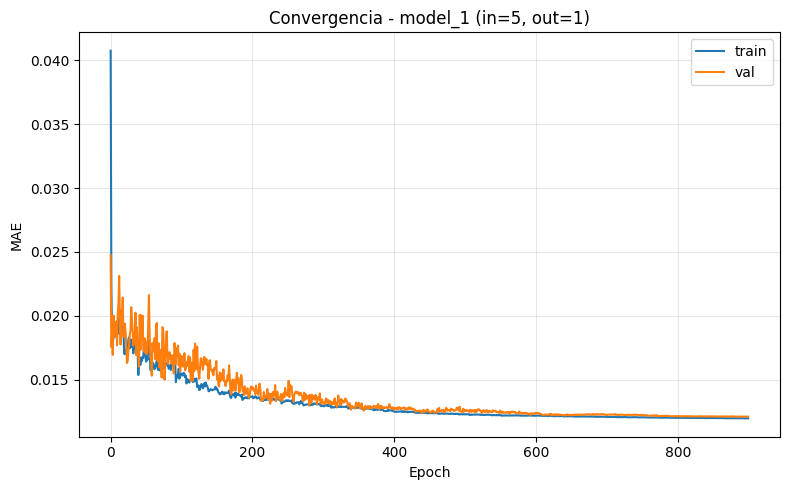

[02/16] Entrenando model_2 | in= 5 out= 5
conv_s | in= 5 out= 5 | train=0.0056 val=0.0074 test=0.0296 ep=900


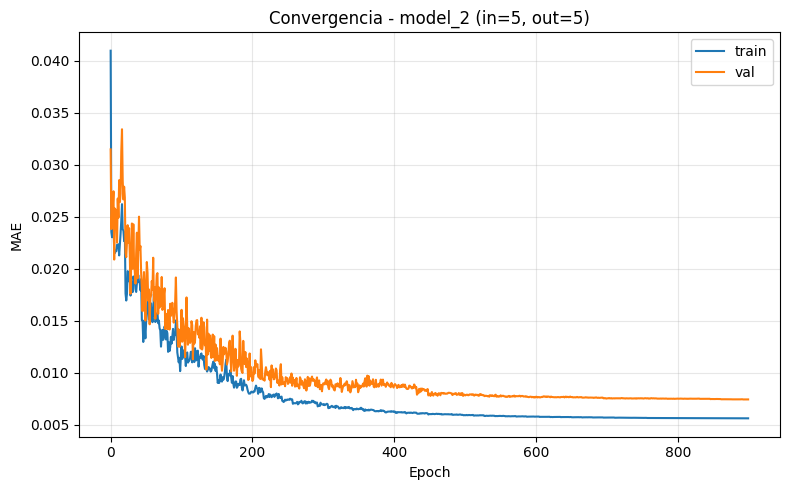

[03/16] Entrenando model_3 | in= 5 out=30
conv_s | in= 5 out=30 | train=0.0023 val=0.0055 test=0.0172 ep=900


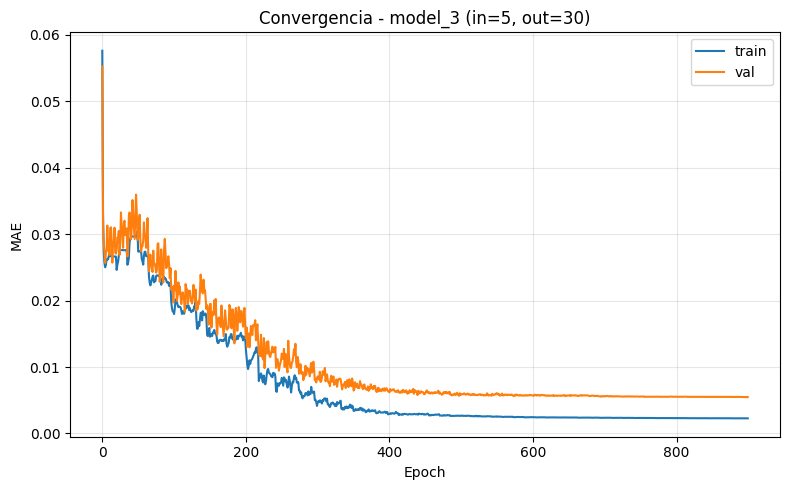

[04/16] Entrenando model_4 | in= 5 out=90
conv_s | in= 5 out=90 | train=0.0013 val=0.0025 test=0.0098 ep=900


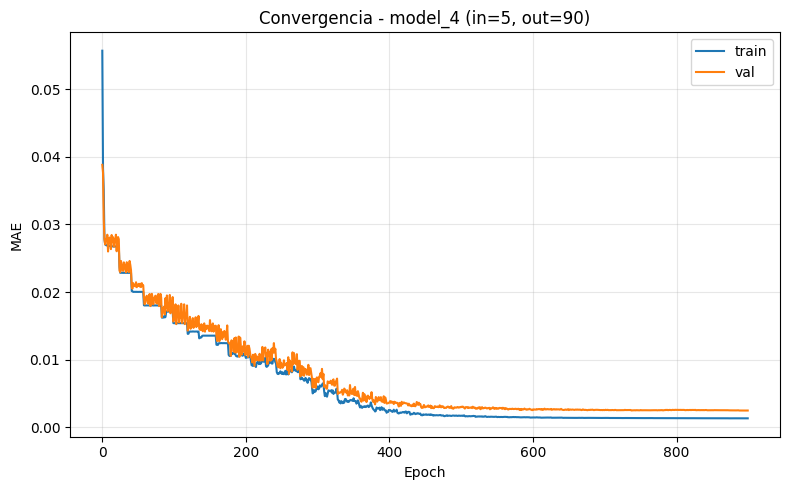

[05/16] Entrenando model_5 | in=10 out= 1
conv_s | in=10 out= 1 | train=0.0120 val=0.0123 test=0.0180 ep=900


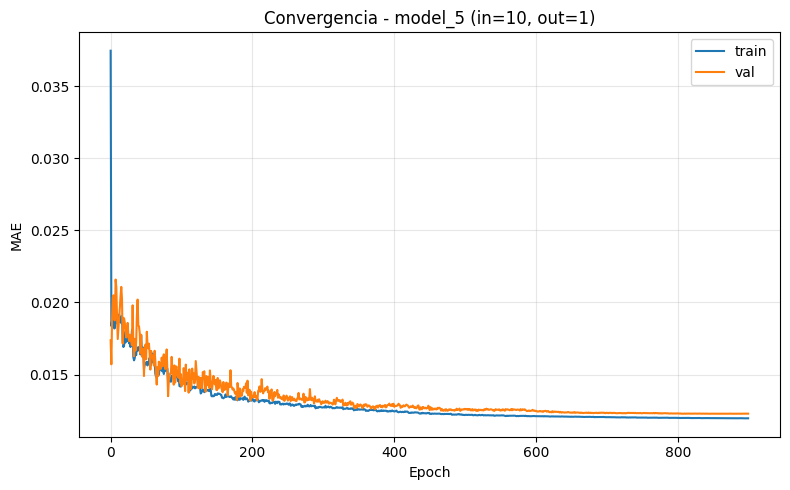

[06/16] Entrenando model_6 | in=10 out= 5
conv_s | in=10 out= 5 | train=0.0056 val=0.0057 test=0.0175 ep=900


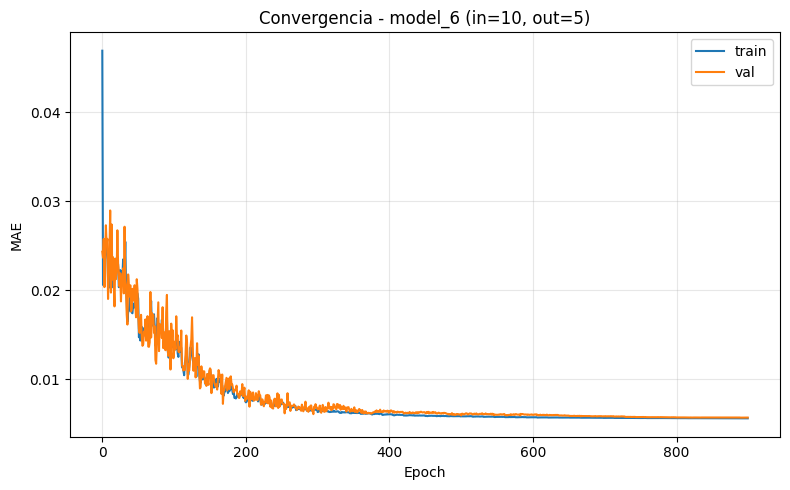

[07/16] Entrenando model_7 | in=10 out=30
conv_s | in=10 out=30 | train=0.0023 val=0.0038 test=0.0070 ep=900


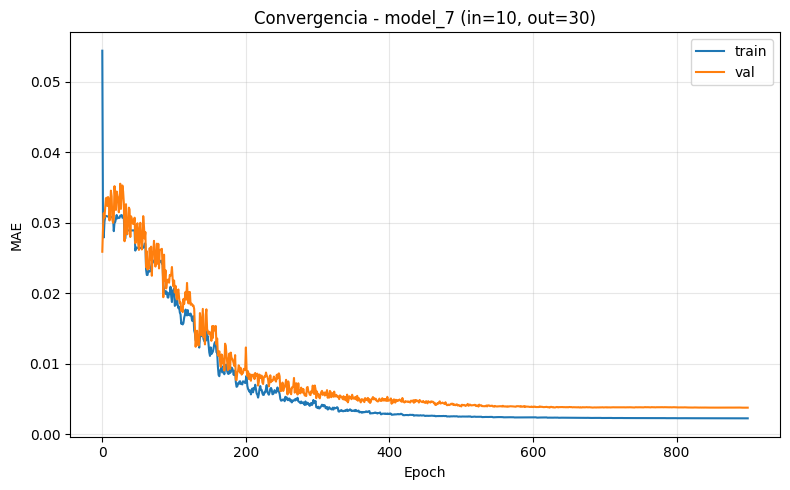

[08/16] Entrenando model_8 | in=10 out=90
conv_s | in=10 out=90 | train=0.0013 val=0.0051 test=0.0134 ep=900


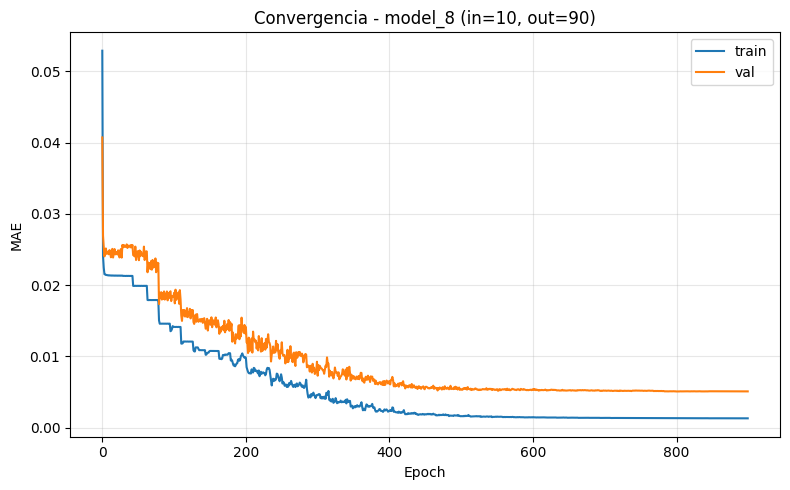

[09/16] Entrenando model_9 | in=30 out= 1
conv_s | in=30 out= 1 | train=0.0120 val=0.0138 test=0.0243 ep=900


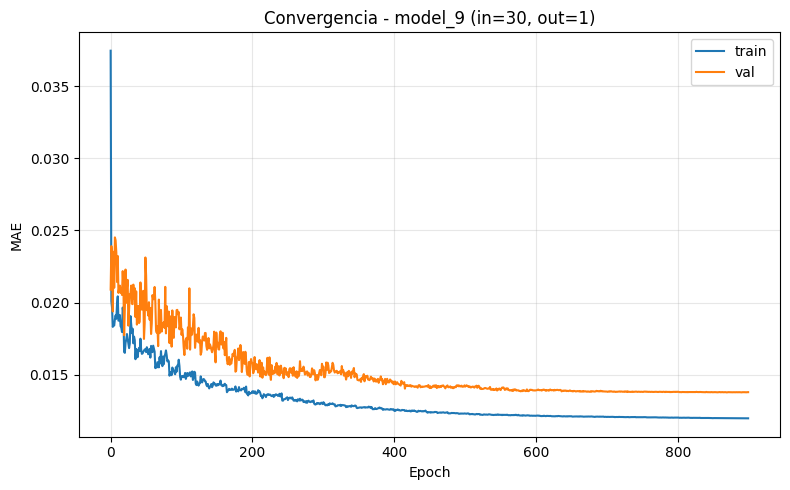

[10/16] Entrenando model_10 | in=30 out= 5
conv_s | in=30 out= 5 | train=0.0056 val=0.0060 test=0.0112 ep=900


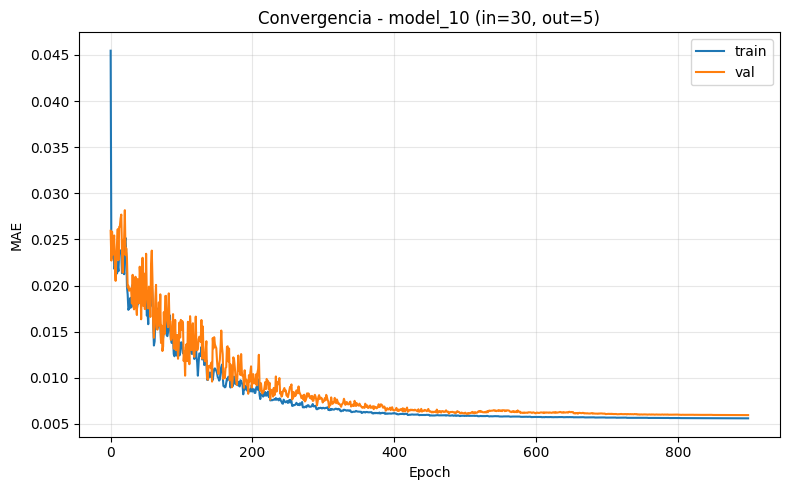

[11/16] Entrenando model_11 | in=30 out=30
conv_s | in=30 out=30 | train=0.0023 val=0.0032 test=0.0057 ep=900


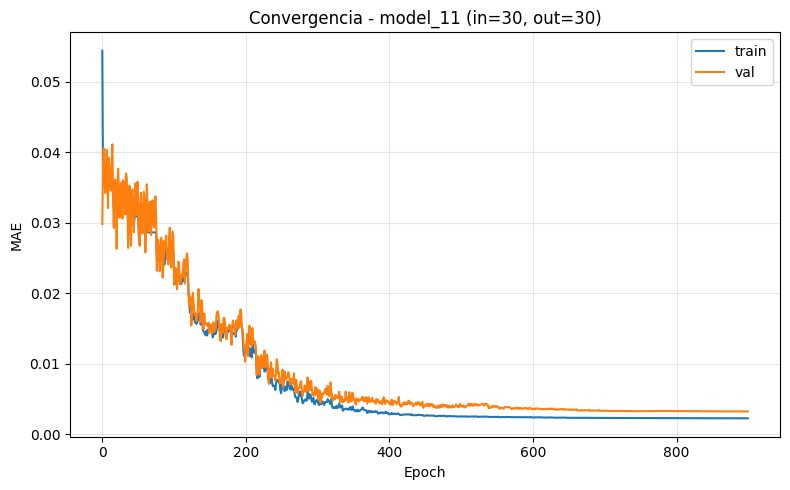

[12/16] Entrenando model_12 | in=30 out=90
conv_s | in=30 out=90 | train=0.0013 val=0.0026 test=0.0092 ep=900


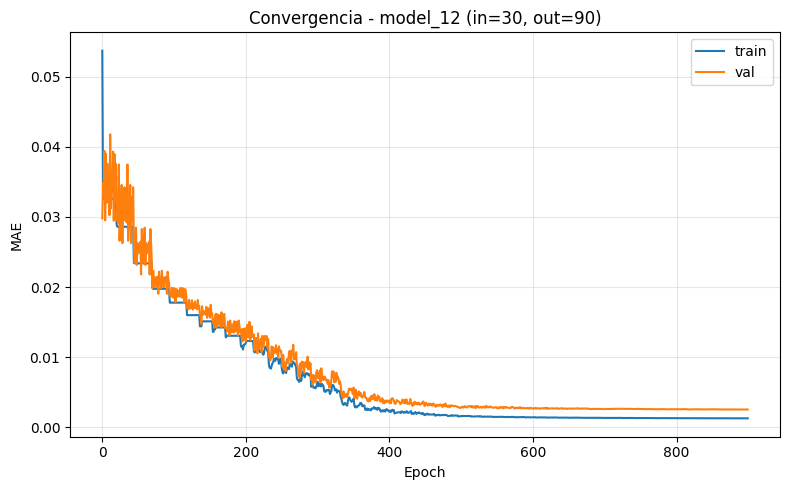

[13/16] Entrenando model_13 | in=90 out= 1
conv_s | in=90 out= 1 | train=0.0120 val=0.0107 test=0.0161 ep=900


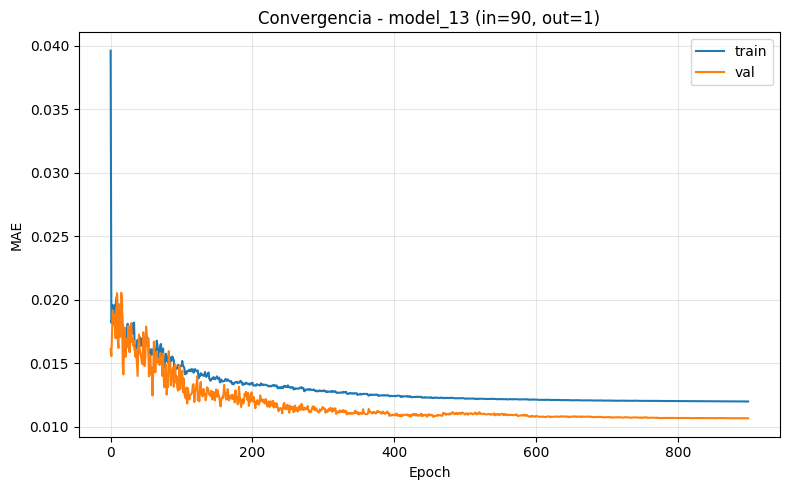

[14/16] Entrenando model_14 | in=90 out= 5
conv_s | in=90 out= 5 | train=0.0056 val=0.0076 test=0.0160 ep=900


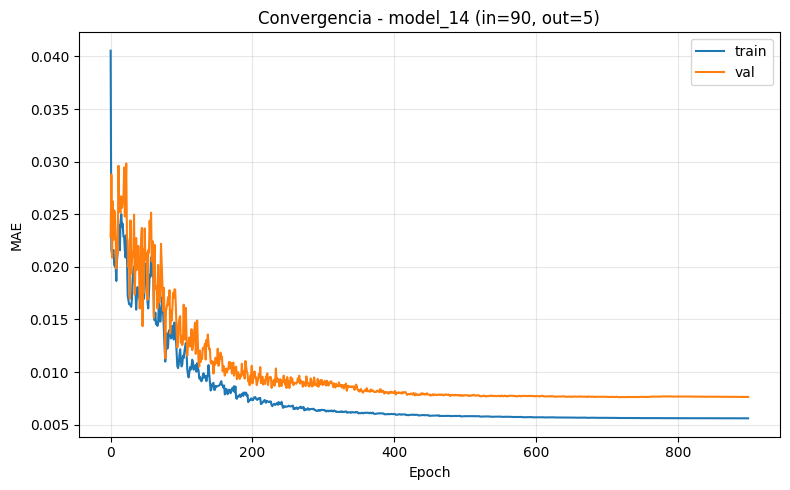

[15/16] Entrenando model_15 | in=90 out=30
conv_s | in=90 out=30 | train=0.0023 val=0.0025 test=0.0087 ep=900


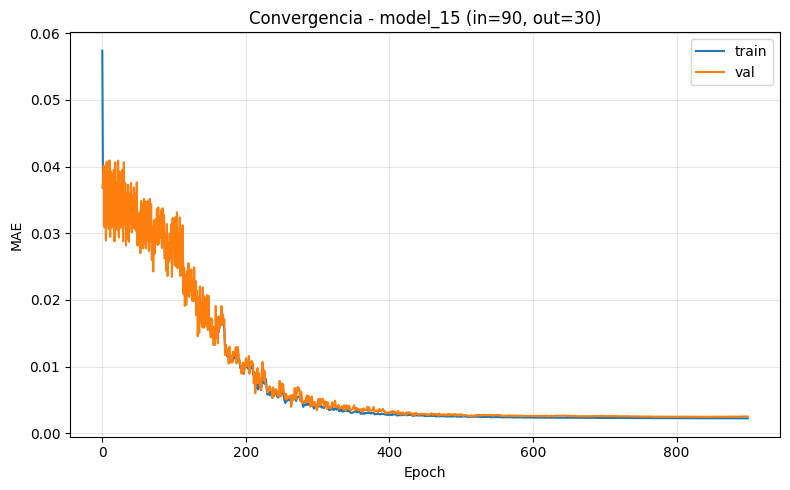

[16/16] Entrenando model_16 | in=90 out=90
conv_s | in=90 out=90 | train=0.0013 val=0.0031 test=0.0108 ep=900


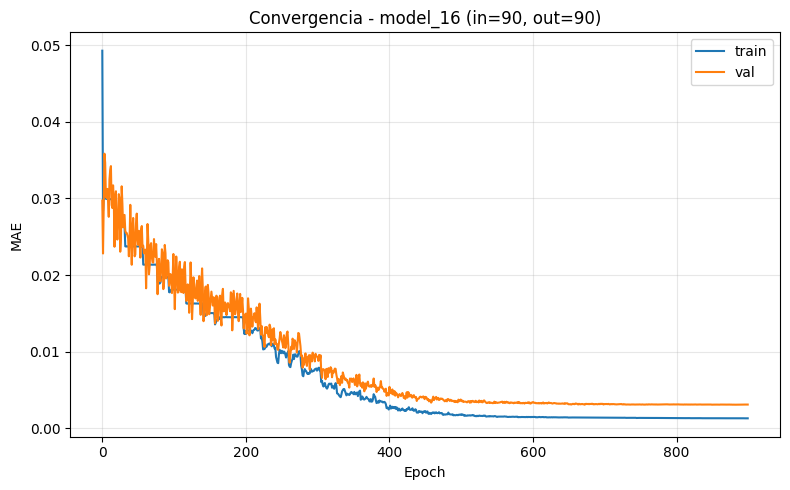

Entrenamiento total terminado.


In [52]:
# CELDA 2: entrenamiento

tf.keras.backend.clear_session()

combos = [(v_in, v_out) for v_in in V_INS for v_out in V_OUTS]

conv_models = {}
conv_histories = {}
conv_results = []
conv_split_mats = {
    split: pd.DataFrame(index=V_INS, columns=V_OUTS, dtype=float)
    for split in ['train', 'val', 'test']
}

for idx, (V_in, V_out) in enumerate(combos, start=1):
    print(f'[{idx:02d}/{len(combos)}] Entrenando model_{idx} | in={V_in:2d} out={V_out:2d}')

    X, y = create_time_series_data(returns, V_in, V_out)
    X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

    model = build_conv_s_model(V_in)

    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(),
        verbose=0
    )

    restore_best_weights(model)

    result = {
        'train': eval_mae(model, X_tr, y_tr),
        'val':   eval_mae(model, X_v, y_v),
        'test':  eval_mae(model, X_ts, y_ts),
        'params': model.count_params(),
        'ep': len(hist.history['loss'])
    }

    conv_models[(V_in, V_out)] = model
    conv_histories[(V_in, V_out)] = hist

    globals()[f'model_{idx}'] = model
    globals()[f'hist_{idx}'] = hist
    globals()[f'result_{idx}'] = result

    for split in ['train', 'val', 'test']:
        conv_split_mats[split].loc[V_in, V_out] = result[split]

    conv_results.append({
        'modelo': idx,
        'V_in': V_in,
        'V_out': V_out,
        'train': result['train'],
        'val': result['val'],
        'test': result['test'],
        'params': result['params'],
        'ep': result['ep']
    })

    print(
        f'conv_s | in={V_in:2d} out={V_out:2d} | '
        f'train={result["train"]:.4f} '
        f'val={result["val"]:.4f} '
        f'test={result["test"]:.4f} '
        f'ep={result["ep"]}'
    )

    plt.figure(figsize=(8, 5))
    plt.plot(hist.history['loss'], label='train')
    plt.plot(hist.history['val_loss'], label='val')
    plt.title(f'Convergencia - model_{idx} (in={V_in}, out={V_out})')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print('Entrenamiento total terminado.')


,modelo,V_in,V_out,train,val,test,params,ep
0,1,5,1,0.0120,0.0121,0.0299,5975,900
1,2,5,5,0.0056,0.0074,0.0296,5975,900
2,3,5,30,0.0023,0.0055,0.0172,5975,900
3,4,5,90,0.0013,0.0025,0.0098,5975,900
4,5,10,1,0.0120,0.0123,0.0180,5975,900
5,6,10,5,0.0056,0.0057,0.0175,5975,900
6,7,10,30,0.0023,0.0038,0.0070,5975,900
7,8,10,90,0.0013,0.0051,0.0134,5975,900
8,9,30,1,0.0120,0.0138,0.0243,5975,900
9,10,30,5,0.0056,0.0060,0.0112,5975,900


Conv1D - MAE train


,1,5,30,90
5,0.012,0.0056,0.0023,0.0013
10,0.012,0.0056,0.0023,0.0013
30,0.012,0.0056,0.0023,0.0013
90,0.012,0.0056,0.0023,0.0013


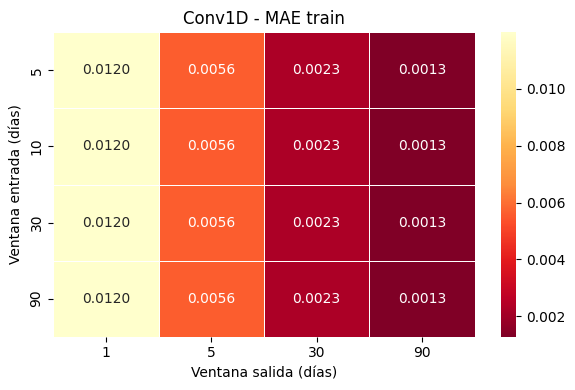

Conv1D - MAE val


,1,5,30,90
5,0.0121,0.0074,0.0055,0.0025
10,0.0123,0.0057,0.0038,0.0051
30,0.0138,0.0060,0.0032,0.0026
90,0.0107,0.0076,0.0025,0.0031


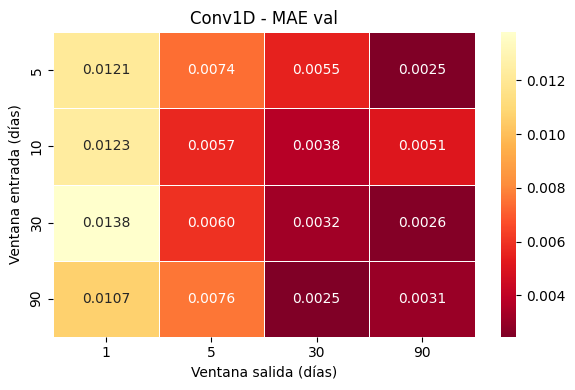

Conv1D - MAE test


,1,5,30,90
5,0.0299,0.0296,0.0172,0.0098
10,0.0180,0.0175,0.0070,0.0134
30,0.0243,0.0112,0.0057,0.0092
90,0.0161,0.0160,0.0087,0.0108


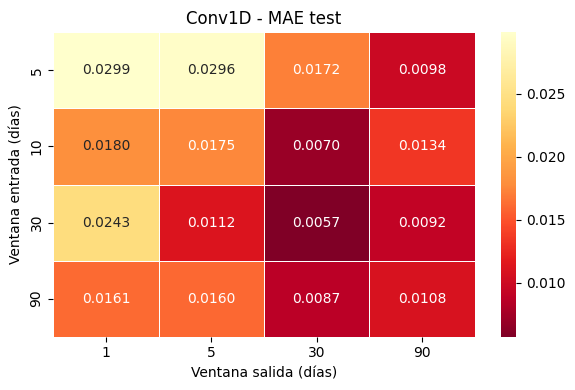

In [53]:
# CELDA 3: resumen global + matrices de color

if 'conv_results' not in globals() or 'conv_split_mats' not in globals():
    raise ValueError('Ejecuta antes la celda de entrenamiento.')

df_conv_resumen = pd.DataFrame(conv_results).sort_values('modelo').reset_index(drop=True)
display(df_conv_resumen.round(4))

for split in ['train', 'val', 'test']:
    print(f'Conv1D - MAE {split}')
    display(conv_split_mats[split].round(4))
    plot_mae_matrix(conv_split_mats[split], title=f'Conv1D - MAE {split}')


# Implementación de modelos complejos 

## Arquitectura alternativa: Conv1D más profunda

Además del modelo Conv1D simple, se plantea una arquitectura más compleja para comprobar si aumentar la capacidad del modelo cambia los resultados obtenidos.

El objetivo principal no es asumir que una red más grande será necesariamente mejor, sino analizar si el comportamiento observado en el modelo base se mantiene o si una arquitectura con mayor profundidad consigue capturar patrones que el modelo simple no detecta.

```python
models = Sequential([
    Input((v_in, 23)),

    Conv1D(64, kernel_size=3, padding='same', activation='relu',
           kernel_regularizer=l2(l2_reg)),

    Conv1D(64, kernel_size=3, padding='same', activation='relu',
           kernel_regularizer=l2(l2_reg)),

    Conv1D(128, kernel_size=3, padding='same', activation='relu',
           kernel_regularizer=l2(l2_reg)),

    GlobalAveragePooling1D(),

    Dense(64, activation='relu', kernel_regularizer=l2(l2_reg)),

    Dense(23)
])
```

---

### Objetivo del experimento

Con esta arquitectura se quiere comprobar si los resultados varían al utilizar un modelo con mayor capacidad de aprendizaje.

En el modelo anterior solo se utilizaba una capa `Conv1D`, mientras que en este caso se apilan varias capas convolucionales y se añade una capa densa intermedia antes de la salida final.

La idea es evaluar si una red más profunda puede aprender relaciones temporales más complejas o si, por el contrario, el modelo sigue mostrando un comportamiento similar al modelo simple.

---

### Decisiones de diseño

| # | Decisión | Alternativa comparada | Justificación |
|---|---|---|---|
| D1 | **Aumentar la profundidad del modelo** | Usar una única capa `Conv1D` | Se quiere comprobar si varias capas convolucionales permiten extraer patrones temporales más elaborados que una sola capa. |
| D2 | **Tres capas `Conv1D` consecutivas** | Mantener una arquitectura Conv1D simple | Apilar convoluciones permite que las primeras capas detecten patrones locales simples y las siguientes combinen esos patrones en representaciones más complejas. |
| D3 | **Filtros 64 → 64 → 128** | Mantener siempre el mismo número de filtros | Se aumenta la capacidad en la última capa convolucional para permitir que el modelo construya una representación más rica antes del pooling global. |
| D4 | **Uso de `padding='same'`** | Usar convoluciones sin padding | El padding mantiene la longitud temporal tras cada convolución. Esto evita que la secuencia se reduzca demasiado al apilar varias capas. |
| D5 | **Mantener `kernel_size=3`** | Usar kernels temporales más grandes | Se conserva el mismo tamaño de kernel que en el modelo base para que la comparación se centre principalmente en el aumento de profundidad y no en cambiar demasiados factores a la vez. |
| D6 | **Añadir `Dense(64)` antes de la salida** | Pasar directamente de `GlobalAveragePooling1D` a `Dense(23)` | La capa densa intermedia permite combinar de forma no lineal los patrones extraídos por las convoluciones antes de generar la predicción final. |
| D7 | **Salida `Dense(23)`** | Cambiar el número de variables predichas | Se mantiene la misma salida que en el modelo base para que los resultados sean comparables. |

---

### Flujo del modelo

```text
Ventana histórica de datos financieros
        |
        v
Input((v_in, 23))
        |
        v
Conv1D(64, kernel_size=3, padding='same')
        |
        v
Conv1D(64, kernel_size=3, padding='same')
        |
        v
Conv1D(128, kernel_size=3, padding='same')
        |
        v
GlobalAveragePooling1D()
        |
        v
Dense(64, ReLU)
        |
        v
Dense(23)
        |
        v
Predicción de 23 variables
```

---

### Comparación con el modelo simple

| Aspecto | Modelo Conv1D simple | Modelo Conv1D profundo |
|---|---|---|
| Capas convolucionales | 1 | 3 |
| Filtros | 64 | 64, 64 y 128 |
| Capa densa intermedia | No | Sí, `Dense(64)` |
| Capacidad del modelo | Baja-media | Mayor |
| Riesgo de sobreajuste | Menor | Mayor |
| Objetivo | Modelo base | Comprobar si más complejidad mejora los resultados |

---

### Hipótesis a comprobar

La hipótesis principal es:

```text
Si el problema necesita una representación temporal más compleja,
el modelo profundo debería mejorar los resultados frente al modelo Conv1D simple.
```

Sin embargo, también existe la posibilidad contraria:

```text
Si la señal predictiva es débil o el modelo colapsa hacia predicciones cercanas a cero,
aumentar la complejidad no debería mejorar significativamente los resultados.
```

In [13]:
# Configuración del modelo

V_INS = [5, 10, 30, 90]
V_OUTS = [1, 5, 30, 90]

L2_REG = 1e-4
LEARNING_RATE = 0.0001

def build_conv_s_model(v_in, l2_reg=L2_REG, learning_rate=LEARNING_RATE):
    models = Sequential([
    Input((v_in, 23)),
    Conv1D(64, kernel_size=3, padding='same', activation='relu',
           kernel_regularizer=l2(l2_reg)),
    Conv1D(64, kernel_size=3, padding='same', activation='relu',
           kernel_regularizer=l2(l2_reg)),
    Conv1D(128, kernel_size=3, padding='same', activation='relu',
           kernel_regularizer=l2(l2_reg)),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu', kernel_regularizer=l2(l2_reg)),
    Dense(23)
])
    
    early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

    models.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mae',
        metrics=['mae']
    )
    
    return models

In [9]:
for V_in in V_INS:
    print(f'\n{"─"*50}\nconv_s  (V_in={V_in})\n{"─"*50}')
    build_conv_s_model(V_in).summary()



──────────────────────────────────────────────────
conv_s  (V_in=5)
──────────────────────────────────────────────────


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 5, 64)          │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 5, 64)          │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 5, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,287 (200.34 KB)

 Trainable params: 51,287 (200.34 KB)

...

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_15 (Conv1D)              │ (None, 90, 64)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_16 (Conv1D)              │ (None, 90, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_17 (Conv1D)              │ (None, 90, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,287 (200.34 KB)

 Trainable params: 51,287 (200.34 KB)

 Non-trainable params: 0 (0.00 B)

[01/16] Entrenando model_1 | in= 5 out= 1
conv_s | in= 5 out= 1 | train=0.0119 val=0.0104 test=0.0123 ep=700


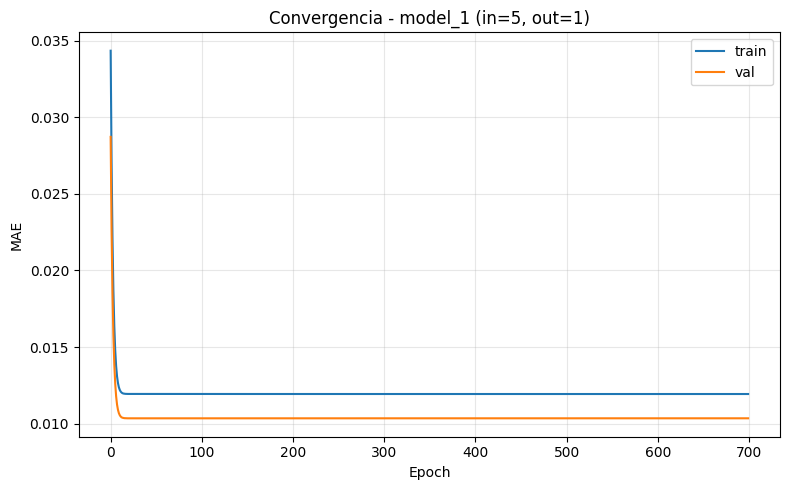

[02/16] Entrenando model_2 | in= 5 out= 5
conv_s | in= 5 out= 5 | train=0.0056 val=0.0046 test=0.0056 ep=700


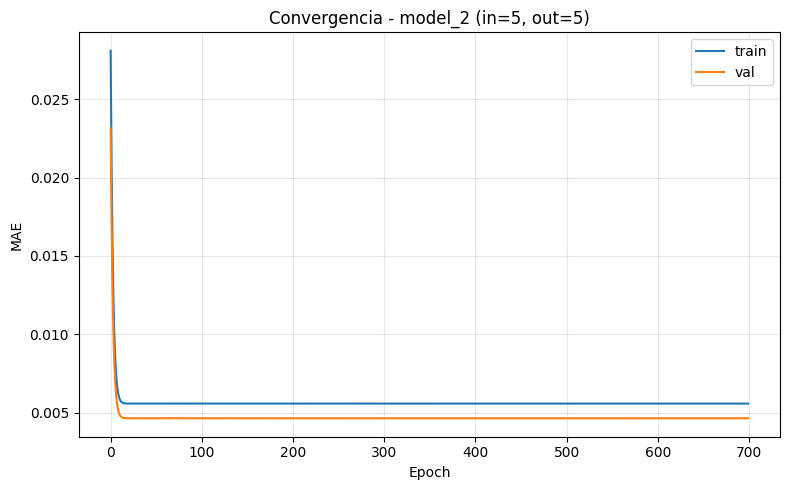

[03/16] Entrenando model_3 | in= 5 out=30
conv_s | in= 5 out=30 | train=0.0022 val=0.0019 test=0.0023 ep=700


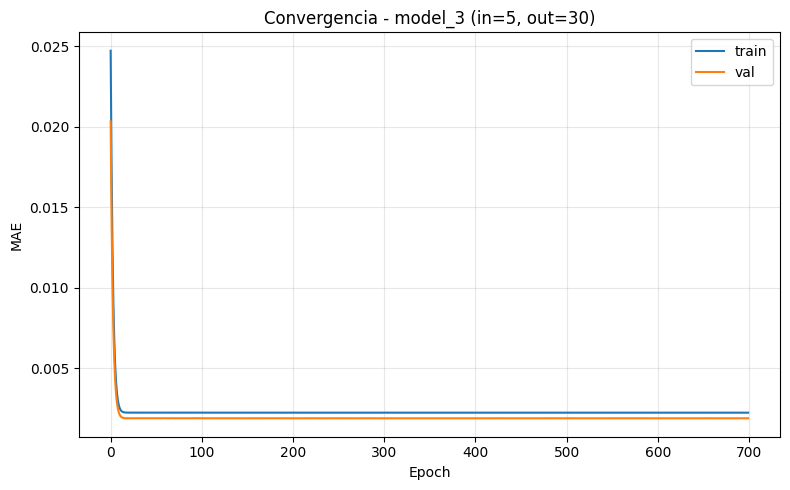

[04/16] Entrenando model_4 | in= 5 out=90
conv_s | in= 5 out=90 | train=0.0013 val=0.0011 test=0.0013 ep=700


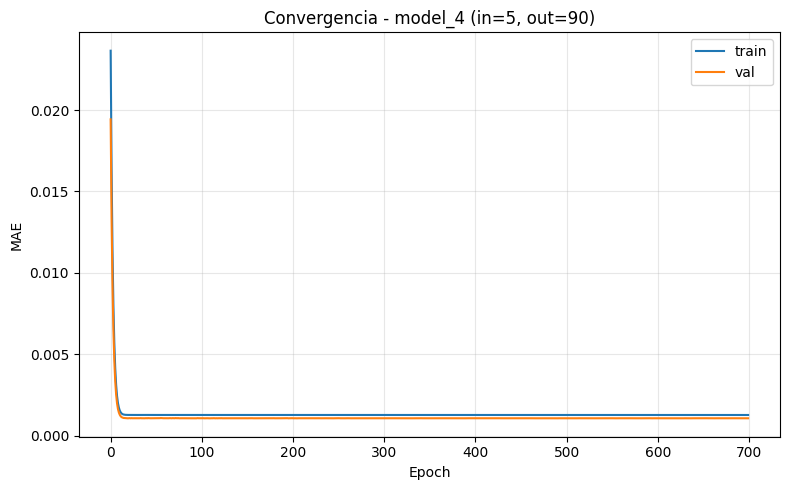

[05/16] Entrenando model_5 | in=10 out= 1
conv_s | in=10 out= 1 | train=0.0119 val=0.0104 test=0.0123 ep=700


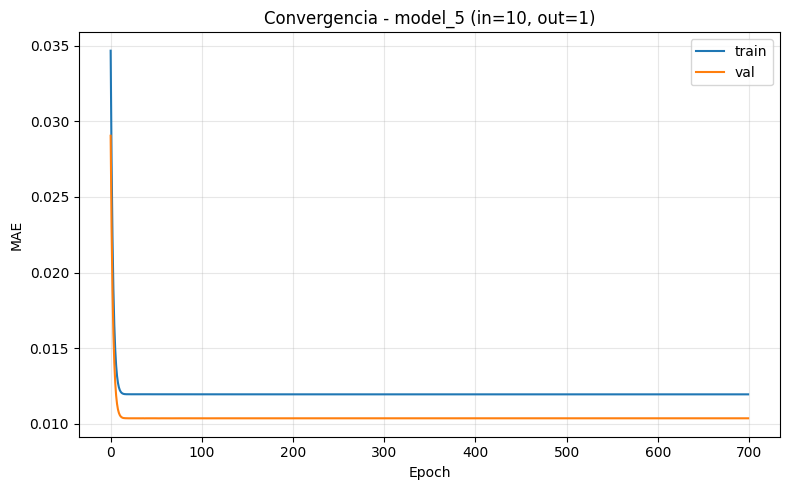

[06/16] Entrenando model_6 | in=10 out= 5
conv_s | in=10 out= 5 | train=0.0056 val=0.0046 test=0.0056 ep=700


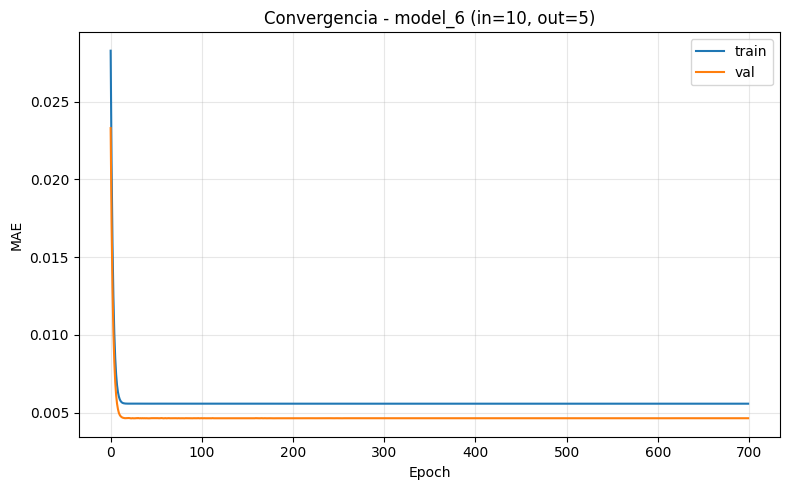

[07/16] Entrenando model_7 | in=10 out=30
conv_s | in=10 out=30 | train=0.0022 val=0.0019 test=0.0023 ep=700


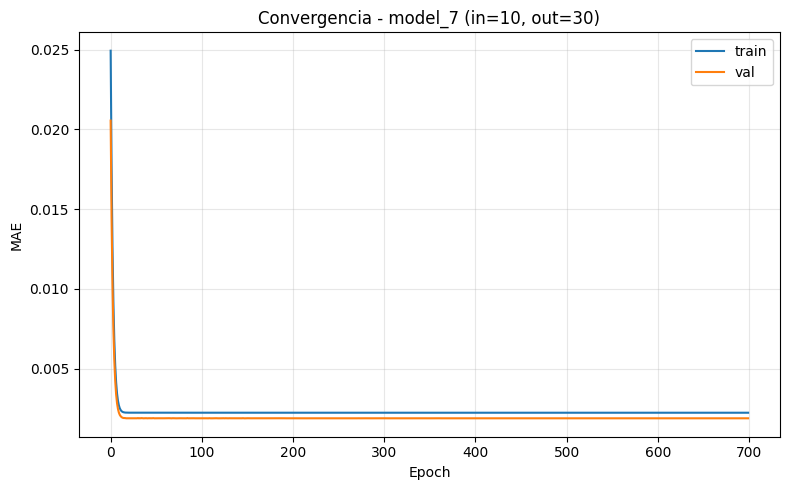

[08/16] Entrenando model_8 | in=10 out=90
conv_s | in=10 out=90 | train=0.0013 val=0.0011 test=0.0013 ep=700


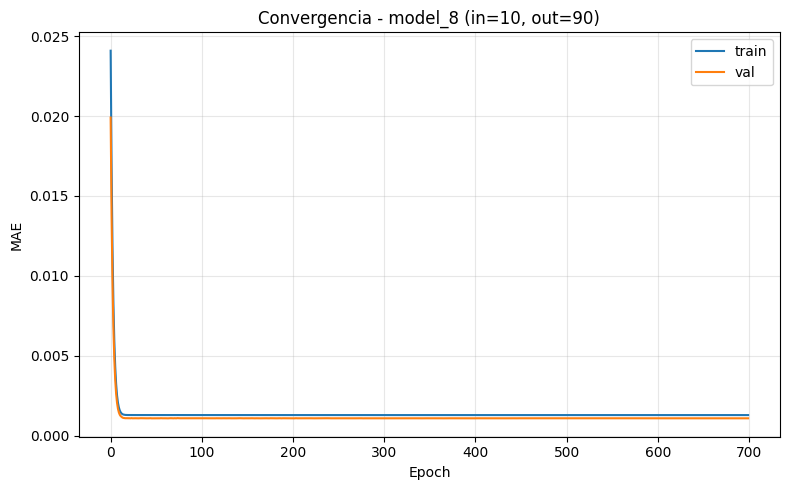

[09/16] Entrenando model_9 | in=30 out= 1
conv_s | in=30 out= 1 | train=0.0119 val=0.0104 test=0.0123 ep=700


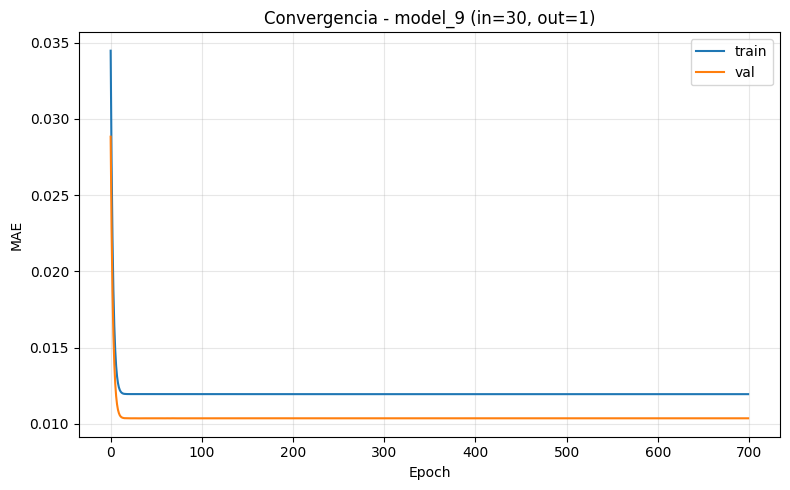

[10/16] Entrenando model_10 | in=30 out= 5
conv_s | in=30 out= 5 | train=0.0056 val=0.0046 test=0.0056 ep=700


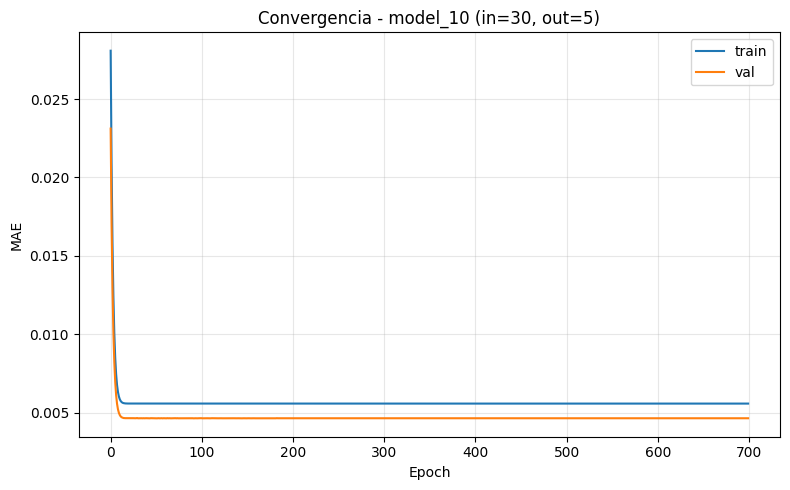

[11/16] Entrenando model_11 | in=30 out=30
conv_s | in=30 out=30 | train=0.0022 val=0.0019 test=0.0023 ep=700


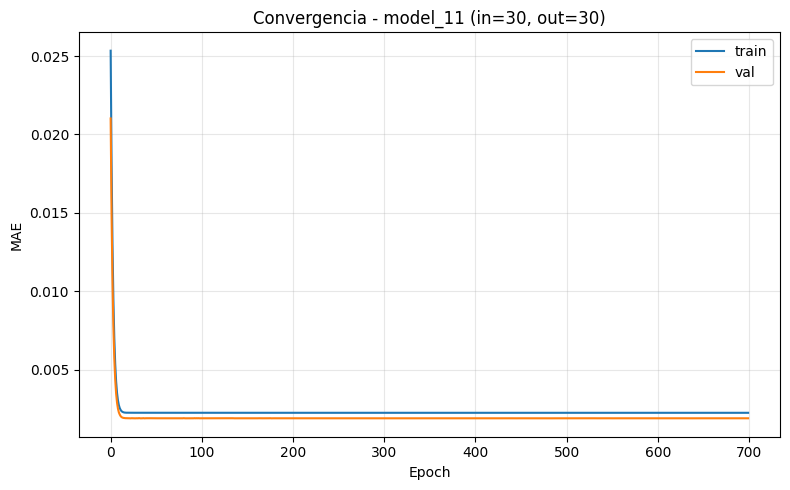

[12/16] Entrenando model_12 | in=30 out=90
conv_s | in=30 out=90 | train=0.0013 val=0.0011 test=0.0013 ep=700


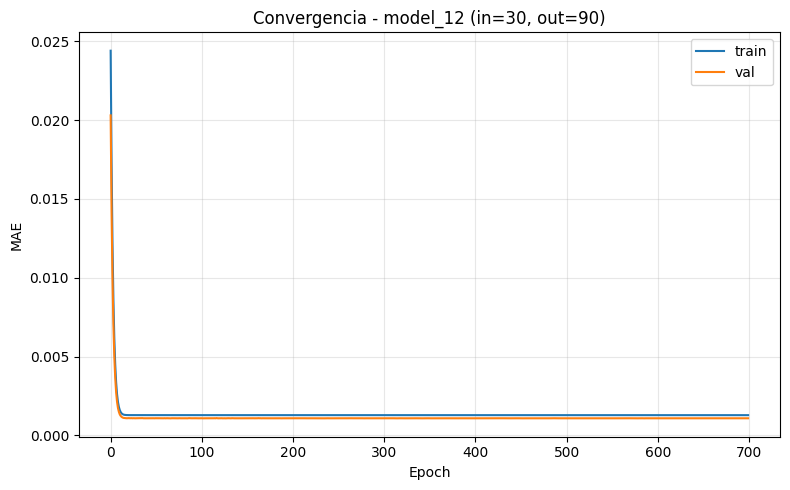

[13/16] Entrenando model_13 | in=90 out= 1
conv_s | in=90 out= 1 | train=0.0120 val=0.0104 test=0.0123 ep=700


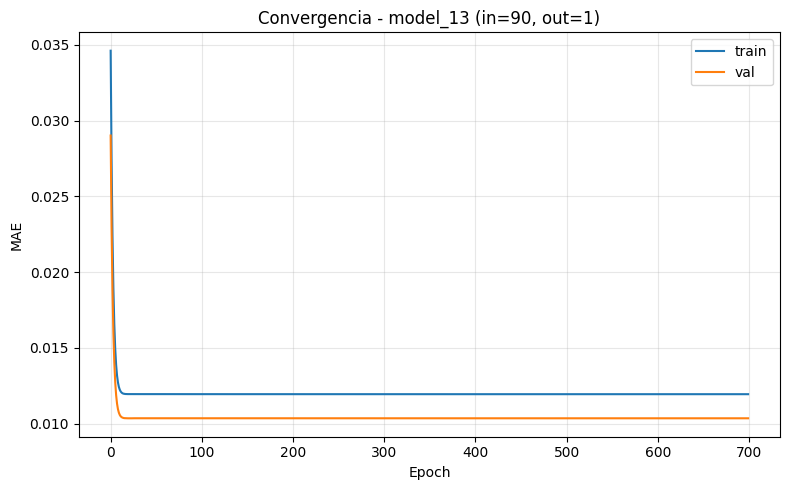

[14/16] Entrenando model_14 | in=90 out= 5
conv_s | in=90 out= 5 | train=0.0056 val=0.0046 test=0.0056 ep=700


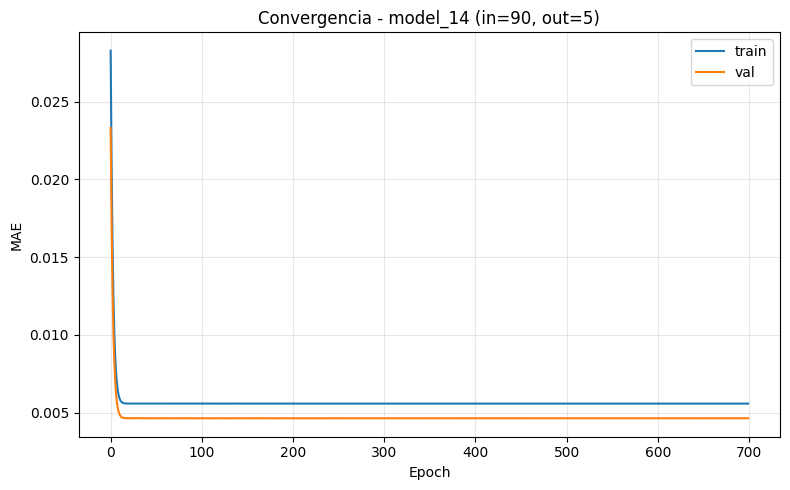

[15/16] Entrenando model_15 | in=90 out=30
conv_s | in=90 out=30 | train=0.0022 val=0.0019 test=0.0023 ep=700


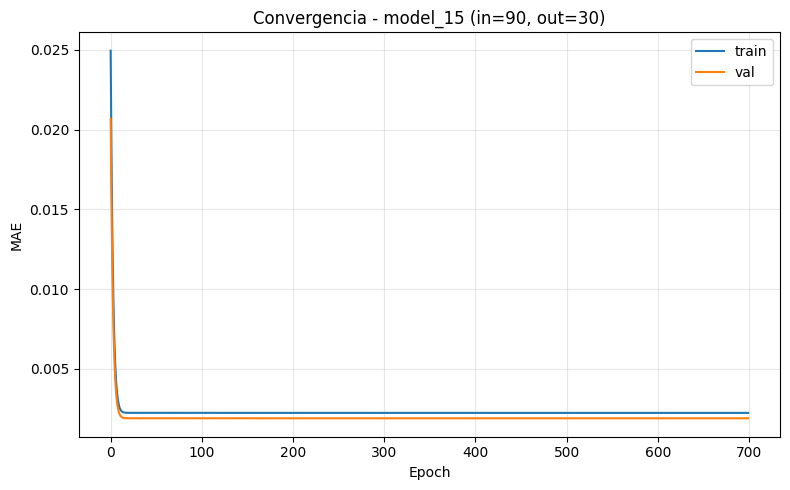

[16/16] Entrenando model_16 | in=90 out=90
conv_s | in=90 out=90 | train=0.0013 val=0.0011 test=0.0013 ep=700


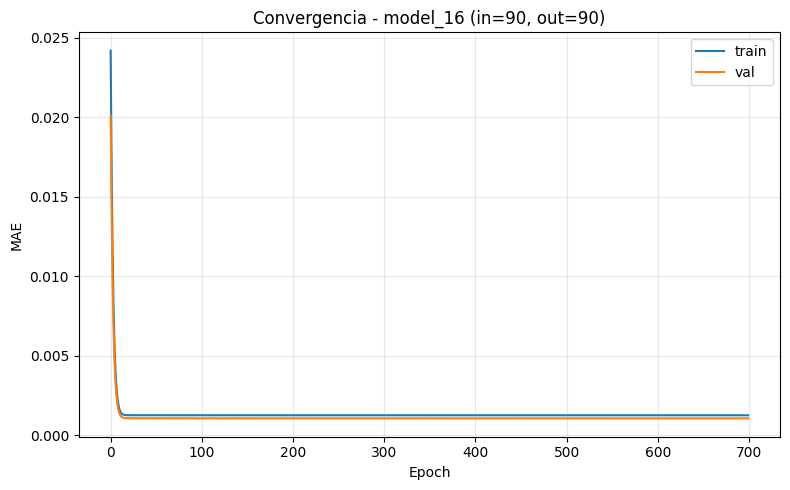

Entrenamiento total terminado.


In [10]:
# CELDA 2: entrenamiento

tf.keras.backend.clear_session()

combos = [(v_in, v_out) for v_in in V_INS for v_out in V_OUTS]

conv_models = {}
conv_histories = {}
conv_results = []
conv_split_mats = {
    split: pd.DataFrame(index=V_INS, columns=V_OUTS, dtype=float)
    for split in ['train', 'val', 'test']
}

for idx, (V_in, V_out) in enumerate(combos, start=1):
    print(f'[{idx:02d}/{len(combos)}] Entrenando model_{idx} | in={V_in:2d} out={V_out:2d}')

    X, y = create_time_series_data(returns, V_in, V_out)
    X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

    model = build_conv_s_model(V_in)

    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(),
        verbose=0
    )

    restore_best_weights(model)

    result = {
        'train': eval_mae(model, X_tr, y_tr),
        'val':   eval_mae(model, X_v, y_v),
        'test':  eval_mae(model, X_ts, y_ts),
        'params': model.count_params(),
        'ep': len(hist.history['loss'])
    }

    conv_models[(V_in, V_out)] = model
    conv_histories[(V_in, V_out)] = hist

    globals()[f'model_{idx}'] = model
    globals()[f'hist_{idx}'] = hist
    globals()[f'result_{idx}'] = result

    for split in ['train', 'val', 'test']:
        conv_split_mats[split].loc[V_in, V_out] = result[split]

    conv_results.append({
        'modelo': idx,
        'V_in': V_in,
        'V_out': V_out,
        'train': result['train'],
        'val': result['val'],
        'test': result['test'],
        'params': result['params'],
        'ep': result['ep']
    })

    print(
        f'conv_s | in={V_in:2d} out={V_out:2d} | '
        f'train={result["train"]:.4f} '
        f'val={result["val"]:.4f} '
        f'test={result["test"]:.4f} '
        f'ep={result["ep"]}'
    )

    plt.figure(figsize=(8, 5))
    plt.plot(hist.history['loss'], label='train')
    plt.plot(hist.history['val_loss'], label='val')
    plt.title(f'Convergencia - model_{idx} (in={V_in}, out={V_out})')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print('Entrenamiento total terminado.')


,modelo,V_in,V_out,train,val,test,params,ep
0,1,5,1,0.0119,0.0104,0.0123,51287,700
1,2,5,5,0.0056,0.0046,0.0056,51287,700
2,3,5,30,0.0022,0.0019,0.0023,51287,700
3,4,5,90,0.0013,0.0011,0.0013,51287,700
4,5,10,1,0.0119,0.0104,0.0123,51287,700
5,6,10,5,0.0056,0.0046,0.0056,51287,700
6,7,10,30,0.0022,0.0019,0.0023,51287,700
7,8,10,90,0.0013,0.0011,0.0013,51287,700
8,9,30,1,0.0119,0.0104,0.0123,51287,700
9,10,30,5,0.0056,0.0046,0.0056,51287,700


Conv1D - MAE train


,1,5,30,90
5,0.0119,0.0056,0.0022,0.0013
10,0.0119,0.0056,0.0022,0.0013
30,0.0119,0.0056,0.0022,0.0013
90,0.0120,0.0056,0.0022,0.0013


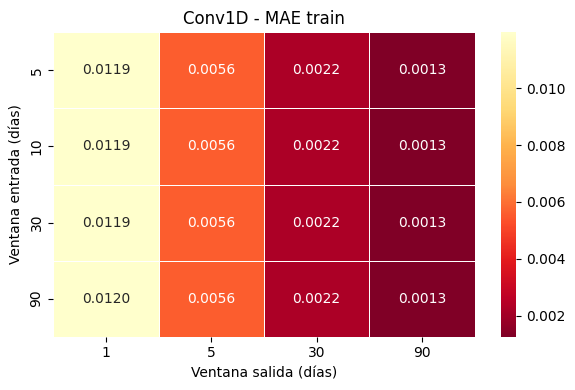

Conv1D - MAE val


,1,5,30,90
5,0.0104,0.0046,0.0019,0.0011
10,0.0104,0.0046,0.0019,0.0011
30,0.0104,0.0046,0.0019,0.0011
90,0.0104,0.0046,0.0019,0.0011


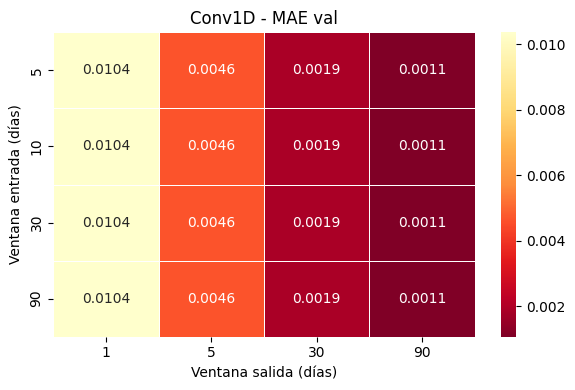

Conv1D - MAE test


,1,5,30,90
5,0.0123,0.0056,0.0023,0.0013
10,0.0123,0.0056,0.0023,0.0013
30,0.0123,0.0056,0.0023,0.0013
90,0.0123,0.0056,0.0023,0.0013


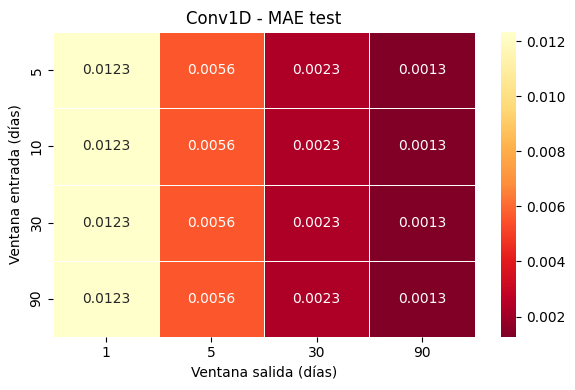

In [11]:
# Resumen global + matrices de color

if 'conv_results' not in globals() or 'conv_split_mats' not in globals():
    raise ValueError('Ejecuta antes la celda de entrenamiento.')

df_conv_resumen = pd.DataFrame(conv_results).sort_values('modelo').reset_index(drop=True)
display(df_conv_resumen.round(4))

for split in ['train', 'val', 'test']:
    print(f'Conv1D - MAE {split}')
    display(conv_split_mats[split].round(4))
    plot_mae_matrix(conv_split_mats[split], title=f'Conv1D - MAE {split}')


# Análisis de los resultados

## Resultados de los modelos

<div style="text-align: justify;">

Como se ha podido observar en los heatmaps de resultados de los modelos simples, el MAE depende principalmente de la ventana de salida. Es decir, para una misma ventana de salida, el resultado es prácticamente el mismo independientemente del número de días usados como entrada. Este mismo comportamiento también aparece en las redes más complejas.

Como ha comprobado mi compañero Daniel con las redes recurrentes, esto se debe a que el modelo parece fijarse casi exclusivamente en el último día de la ventana de entrada, ignorando en gran medida los días anteriores. Por tanto, lo que más influye en el MAE no es tanto la ventana de entrada, sino la ventana de salida que se le exige predecir al modelo.

Además, aunque en train y validación el MAE de los modelos simples no es especialmente malo, en test los resultados empeoran de forma considerable. Por otro lado, aunque los modelos más complejos obtienen un MAE en test mejor que los modelos básicos, tienden a producir resultados muy similares a los obtenidos en train. Esto da pie a la hipótesis que se plantea a continuación en el notebook.

</div>

## ¿Aprenden algo los modelos o son predictores de la media?

In [12]:
V_INS = [5, 10, 30, 90]
V_OUTS = [1, 5, 30, 90]

print(f'{"V_in":>5} {"V_out":>6} | {"MAE media":>10}')
print('-' * 29)

media_results = []

for V_in_t in V_INS:
    for V_out_t in V_OUTS:
        X, y = create_time_series_data(returns, V_in_t, V_out_t)
        Xtr, Xv, Xts, ytr, yv, yts = make_splits(X, y)

        media_train = ytr.mean(axis=0)
        mae_media = np.mean(np.abs(yts - media_train))

        media_results.append({
            'V_in': V_in_t,
            'V_out': V_out_t,
            'mae_media': mae_media
        })

        print(f'{V_in_t:>5} {V_out_t:>6} | {mae_media:>10.4f}')

df_media = pd.DataFrame(media_results)

 V_in  V_out |  MAE media
-----------------------------
    5      1 |     0.0123
    5      5 |     0.0056
    5     30 |     0.0023
    5     90 |     0.0013
   10      1 |     0.0123
   10      5 |     0.0056
   10     30 |     0.0023
   10     90 |     0.0013
   30      1 |     0.0123
   30      5 |     0.0056
   30     30 |     0.0023
   30     90 |     0.0013
   90      1 |     0.0123
   90      5 |     0.0056
   90     30 |     0.0023
   90     90 |     0.0013


<div style="text-align: justify;">

Como indican los resultados, los modelos están obteniendo un MAE muy similar al de un predictor a la media. Esto sugiere que tienden a converger hacia una predicción constante cercana a la media de los retornos, que en este caso equivale a predecir de forma consistente cero, o un valor prácticamente igual a cero.

Este comportamiento puede deberse a que, cuando una red entrenada con MAE recibe datos sin una señal predictiva claramente aprovechable, la respuesta matemáticamente óptima es aproximarse a un valor central de la distribución. En este caso, dado que los retornos están muy concentrados alrededor de cero, el modelo acaba comportándose de forma similar a un predictor constante.

</div>

## Comparación con los modelos de referencia (Naive y Regresión lineal)

<div style="text-align: justify;">

Si bien es verdad que los modelos aprender a predecir la media, siempre y cuando mejores los resultados de los modelos de referencia, pueden llegar a ser de utilidad. 

La red convolucional mejora claramente al modelo naive en todos los horizontes de salida: para `V_out=1` pasa de `0.0178` a `0.0123`, una mejora aproximada del **30,9%**; para `V_out=5` baja de `0.0137` a `0.0056`, mejorando un **59,1%**; para `V_out=30` reduce el MAE de `0.0125` a `0.0023`, una mejora del **81,6%**; y para `V_out=90` pasa de `0.0122` a `0.0013`, lo que supone una mejora aproximada del **89,3%**. Frente a la regresión lineal, los resultados son muy parecidos: con `V_in=5` son prácticamente iguales (`0.0124/0.0056/0.0023/0.0013` frente a `0.0123/0.0056/0.0023/0.0013`), mientras que para ventanas de entrada mayores la convolucional queda ligeramente por debajo en MAE. Por ejemplo, con `V_in=90` mejora de `0.0143` a `0.0123`, de `0.0065` a `0.0056`, de `0.0027` a `0.0023` y de `0.0015` a `0.0013`, con mejoras aproximadas de entre **13% y 15%**.

</div>

## Conclusión

<div style="text-align: justify;">

Dado que los resultados de la regresión lineal son prácticamente iguales a los de las redes convolucionales, se concluye que la inversión de cómputo y tiempo necesaria para entrenar una red neuronal de estas características no parece justificarse en este caso. Para este problema concreto y con los datos disponibles, una regresión lineal básica habría cumplido prácticamente la misma función, obteniendo resultados muy similares con un coste computacional mucho menor.

</div>